# Supplementary EDA figures (thesis-ready)

New and redrawn figures for the report's EDA section. Each is driven by the
canonical precomputed CSVs in `report/img/figures/` (the numbers behind the
report), with the text-length panel computed from the prepared dataset.
Plotting logic lives in [`make_eda_figures_extra.py`](./make_eda_figures_extra.py)
and the shared look in [`eda_style.py`](./eda_style.py). **No original notebook
is modified.**

| Figure | Status | What it shows |
|---|---|---|
| 4 | new (was a table) | Cohort size and study-level text / vitals availability per split |
| 5 | redraw + new panel | Indication-text length distribution + top terms split into clinical signal vs. boilerplate |
| 6 | redraw + new panel | Vital-sign missingness + observed-vs-plausible ranges exposing data-entry outliers |
| 7 | new | Full 40-class CXR-LT 2024 long-tail |

Note: the precomputed CSVs reflect the full 40-class CXR-LT 2024 cohort
(182,882 studies, ~70% with a prior), which is newer than some of the
hard-coded tables in `eda.tex`. Figures 4–7 are regenerated from those CSVs so
they stay consistent with the current dataset.

In [1]:
from pathlib import Path
from IPython.display import Image, display

import make_eda_figures_extra as mx
from eda_style import apply_style

apply_style()

REPO = Path(mx.__file__).resolve().parents[2]
FIG_CSV = REPO / "report" / "img" / "figures"   # precomputed canonical CSVs
DATA_DIR = REPO / "data" / "data-camchex"        # for the text-length panel
OUT_DIR = REPO / "report" / "img" / "eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("csv :", FIG_CSV)
print("out :", OUT_DIR)

csv : /sessions/eloquent-kind-davinci/mnt/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/report/img/figures
out : /sessions/eloquent-kind-davinci/mnt/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/report/img/eda


## Figure 4 — Cohort and modality availability

Currently a table in the report. Left: studies and how many carry indication
text / vital signs, per split. Right: the resulting missingness rate (~15–16%
of studies lack vitals; ~2% lack text).

  fig4: fig4_cohort_modality.png


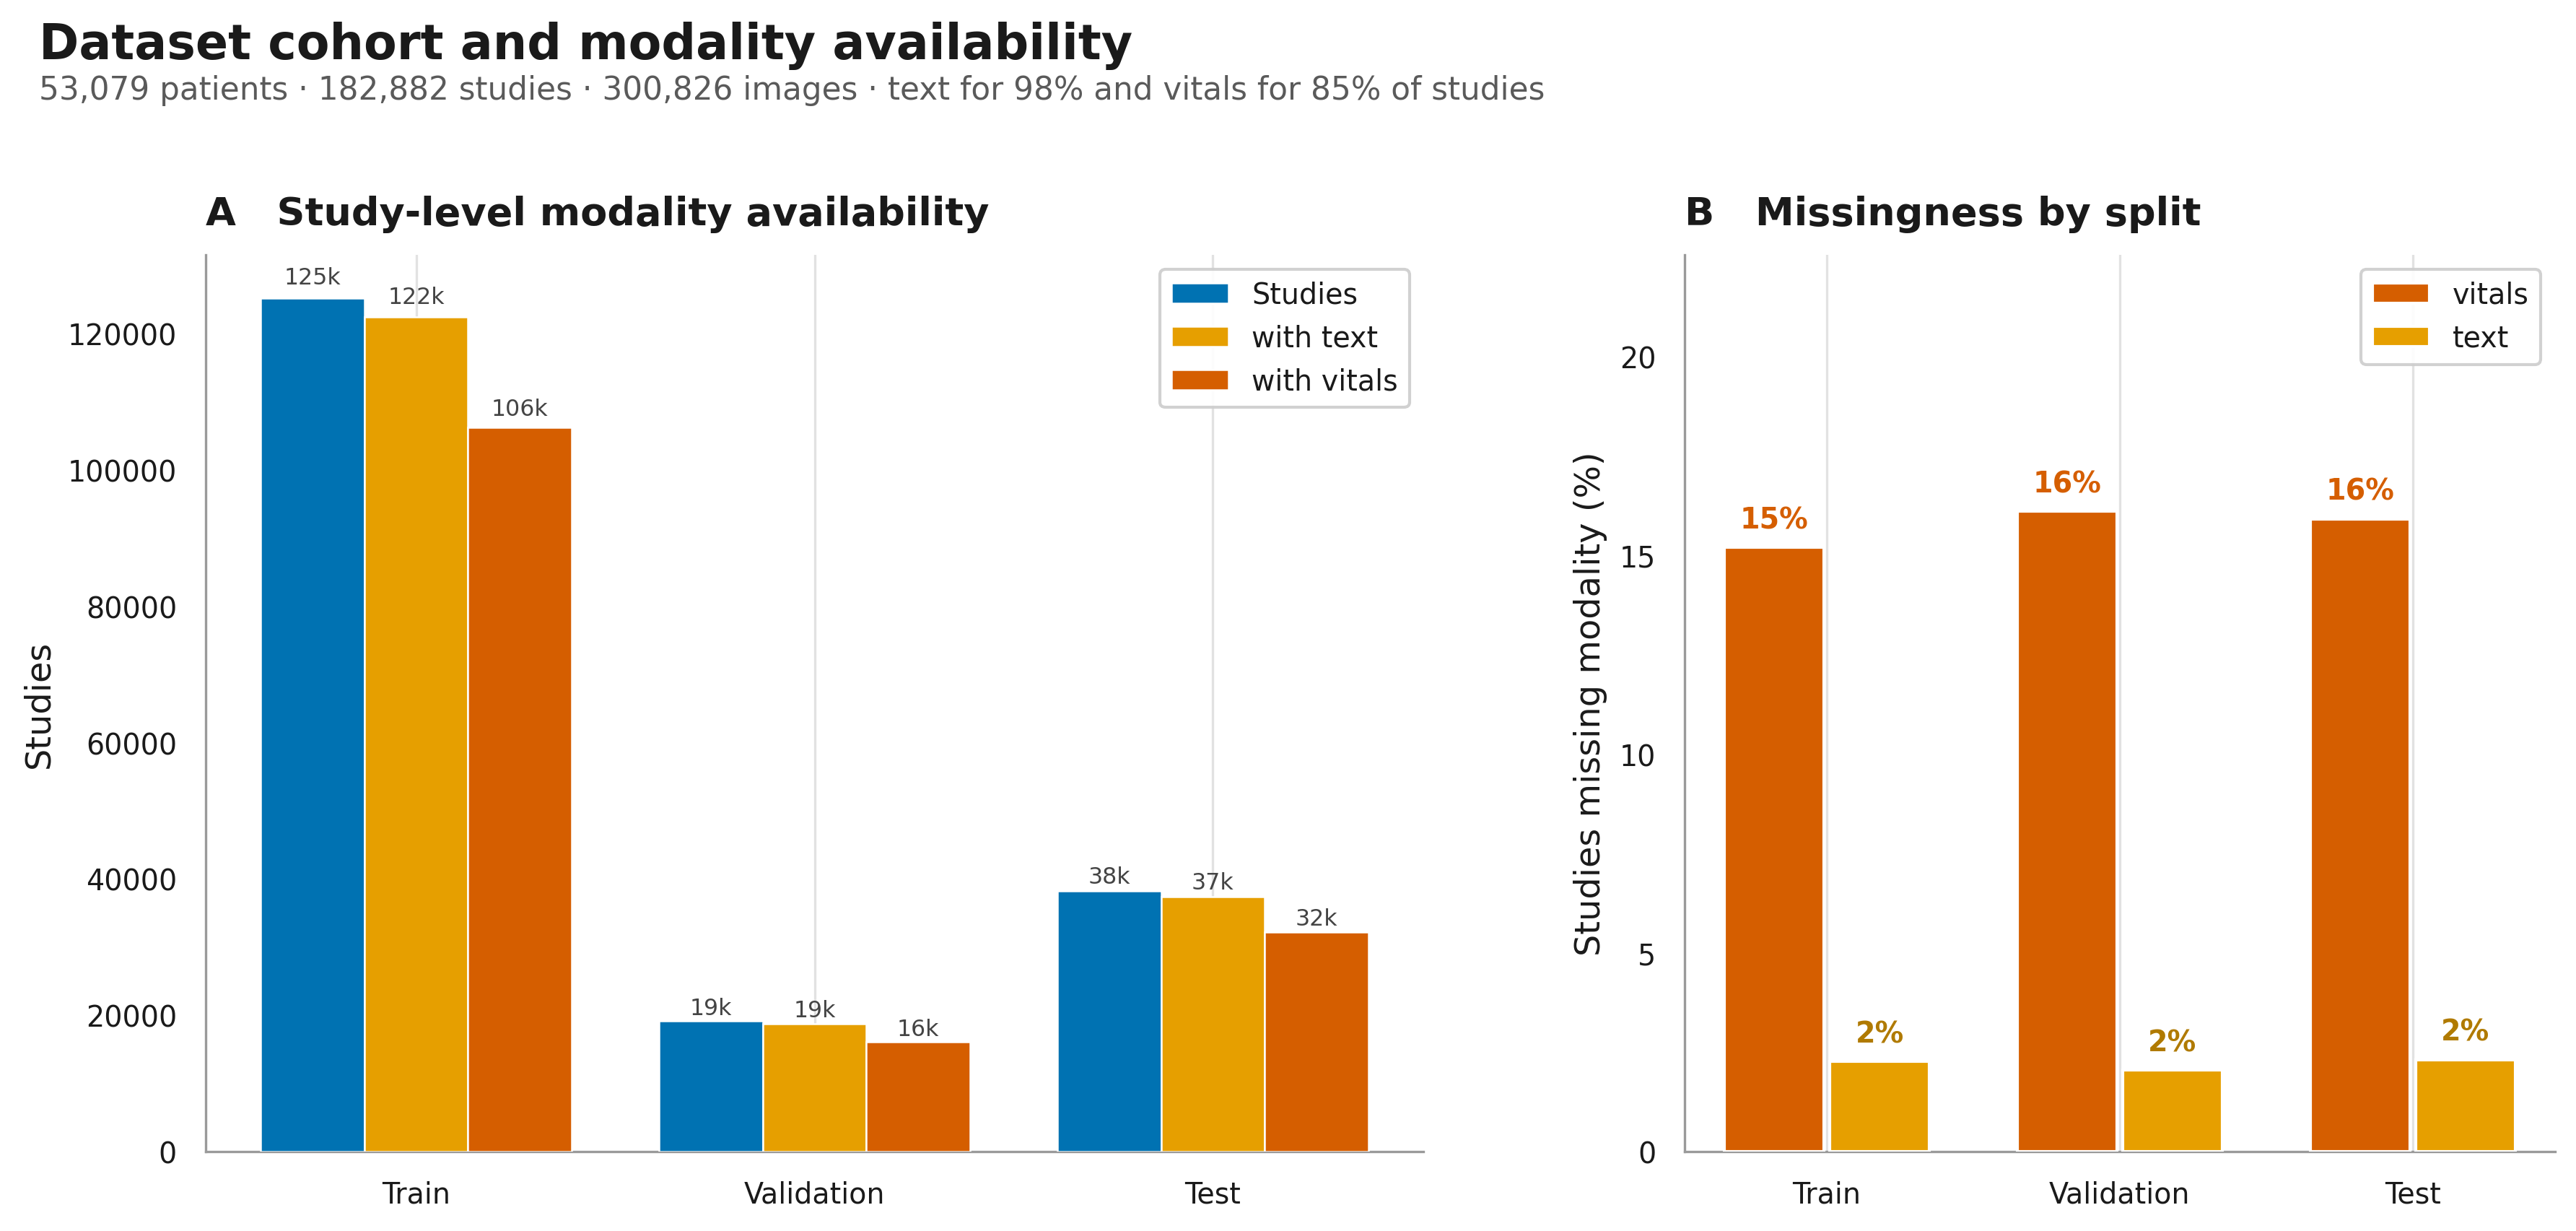

In [2]:
p4 = OUT_DIR / "fig4_cohort_modality.png"
mx.fig_cohort(FIG_CSV, p4)
display(Image(filename=str(p4)))

## Figure 5 — Clinical indication text

Left: indication length is short and right-skewed (median 11 words), supporting
a modest max-token limit. Right: the top-20 terms, colored by whether they are
clinical signal or demographic / template boilerplate.

  fig5: fig5_text.png  (median 11 words)


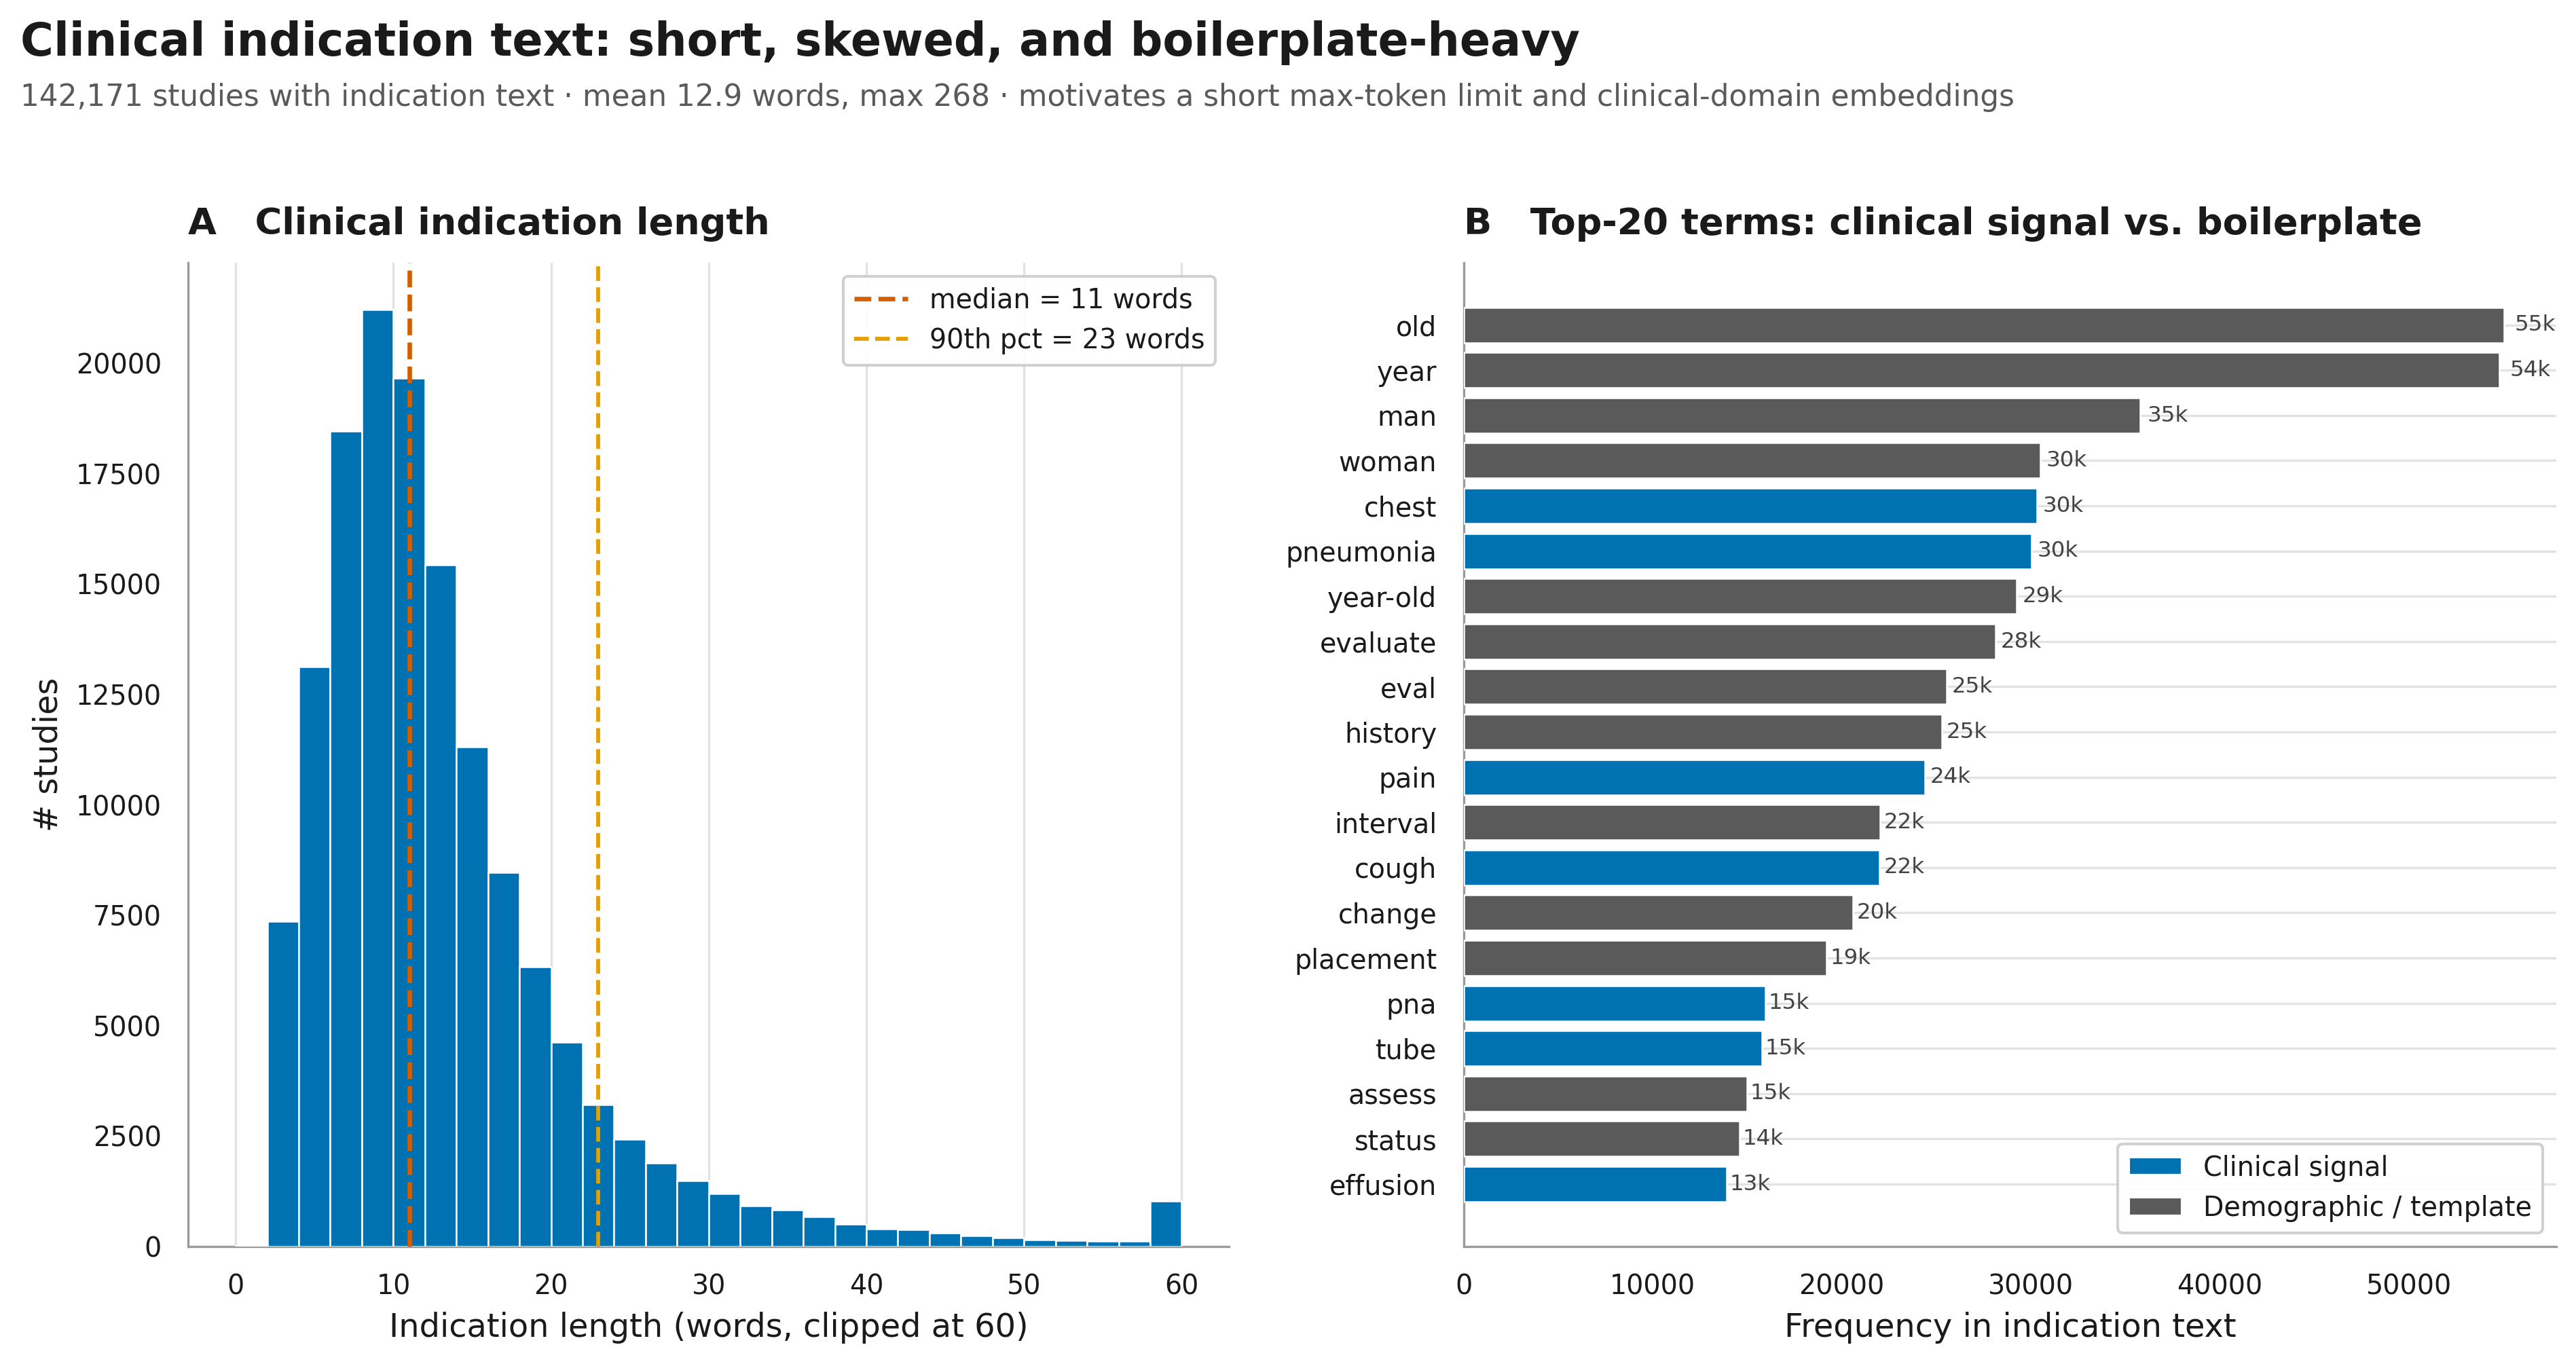

In [3]:
p5 = OUT_DIR / "fig5_text.png"
mx.fig_text(FIG_CSV, DATA_DIR, p5)
display(Image(filename=str(p5)))

## Figure 6 — Vital signs data quality

Left: missingness is uniform across vitals (~15–19%), justifying a single
vitals token + missingness mask. Right: observed min–max vs. a plausible
physiological band on a symlog axis — the long whiskers (e.g. systolic BP to
12,080; diastolic to 74,810) are data-entry errors that motivate outlier
clipping and z-score normalization.

  fig6: fig6_vitals_quality.png


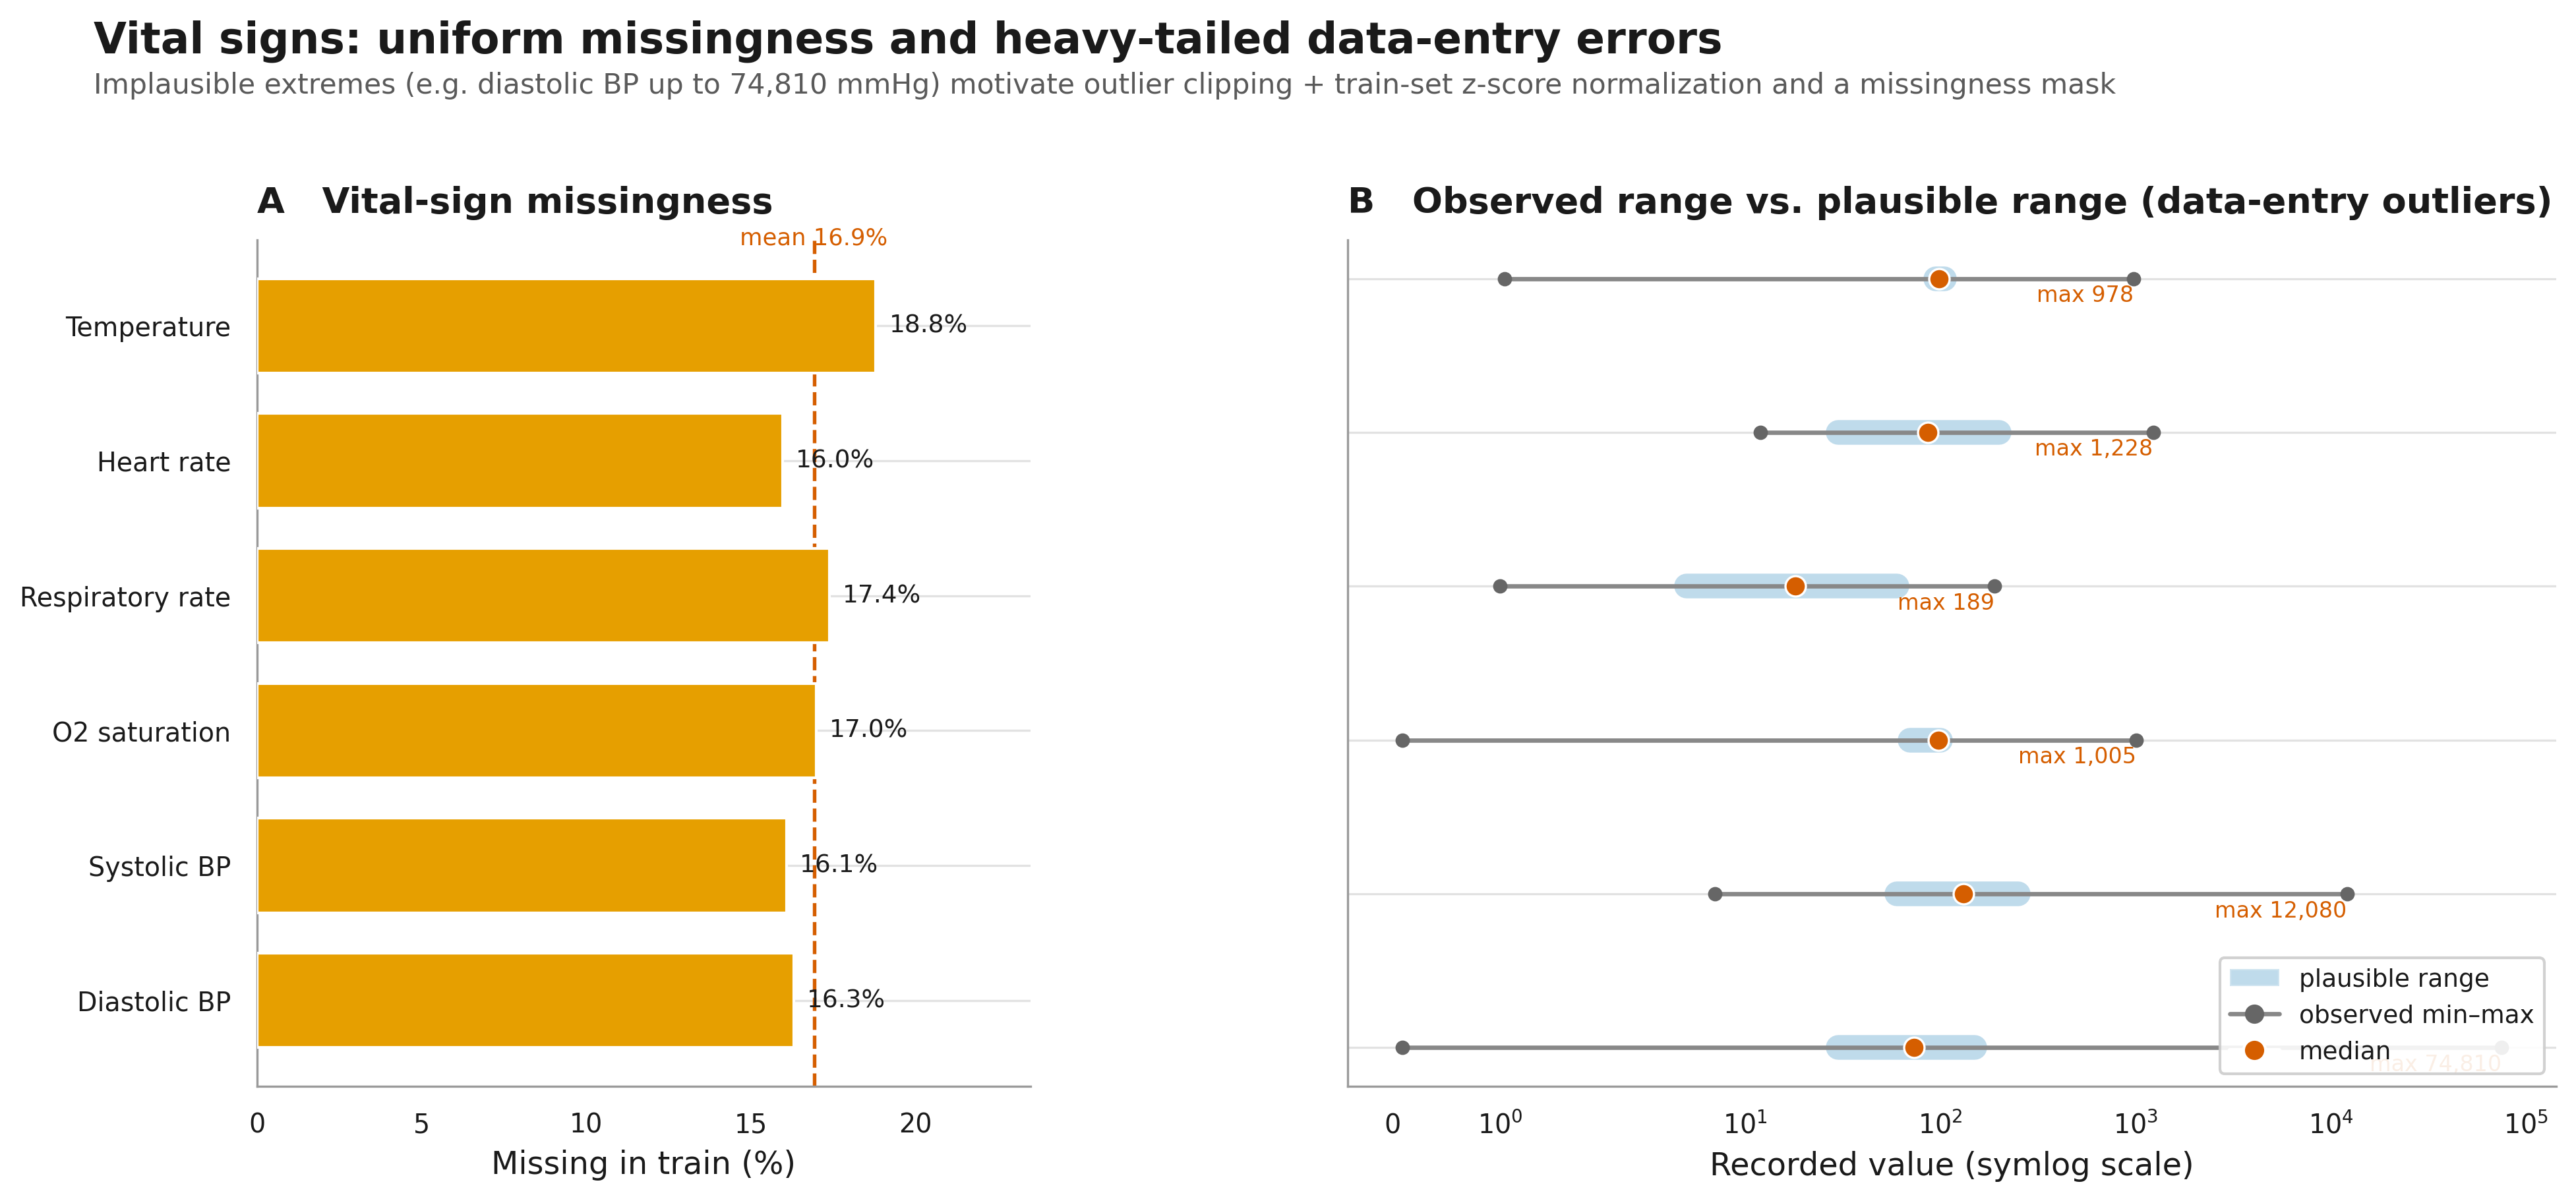

In [4]:
p6 = OUT_DIR / "fig6_vitals_quality.png"
mx.fig_vitals(FIG_CSV, p6)
display(Image(filename=str(p6)))

## Figure 7 — Full 40-class long-tail (CXR-LT 2024)

Extends the 26-class view to the full 40-class task, on a log axis and colored
by frequency tertile. The imbalance spans ~700×, from Clavicle Fracture (106
positive studies) to Support Devices (74,724).

  fig7: fig7_longtail40.png  (40 classes, 705x)


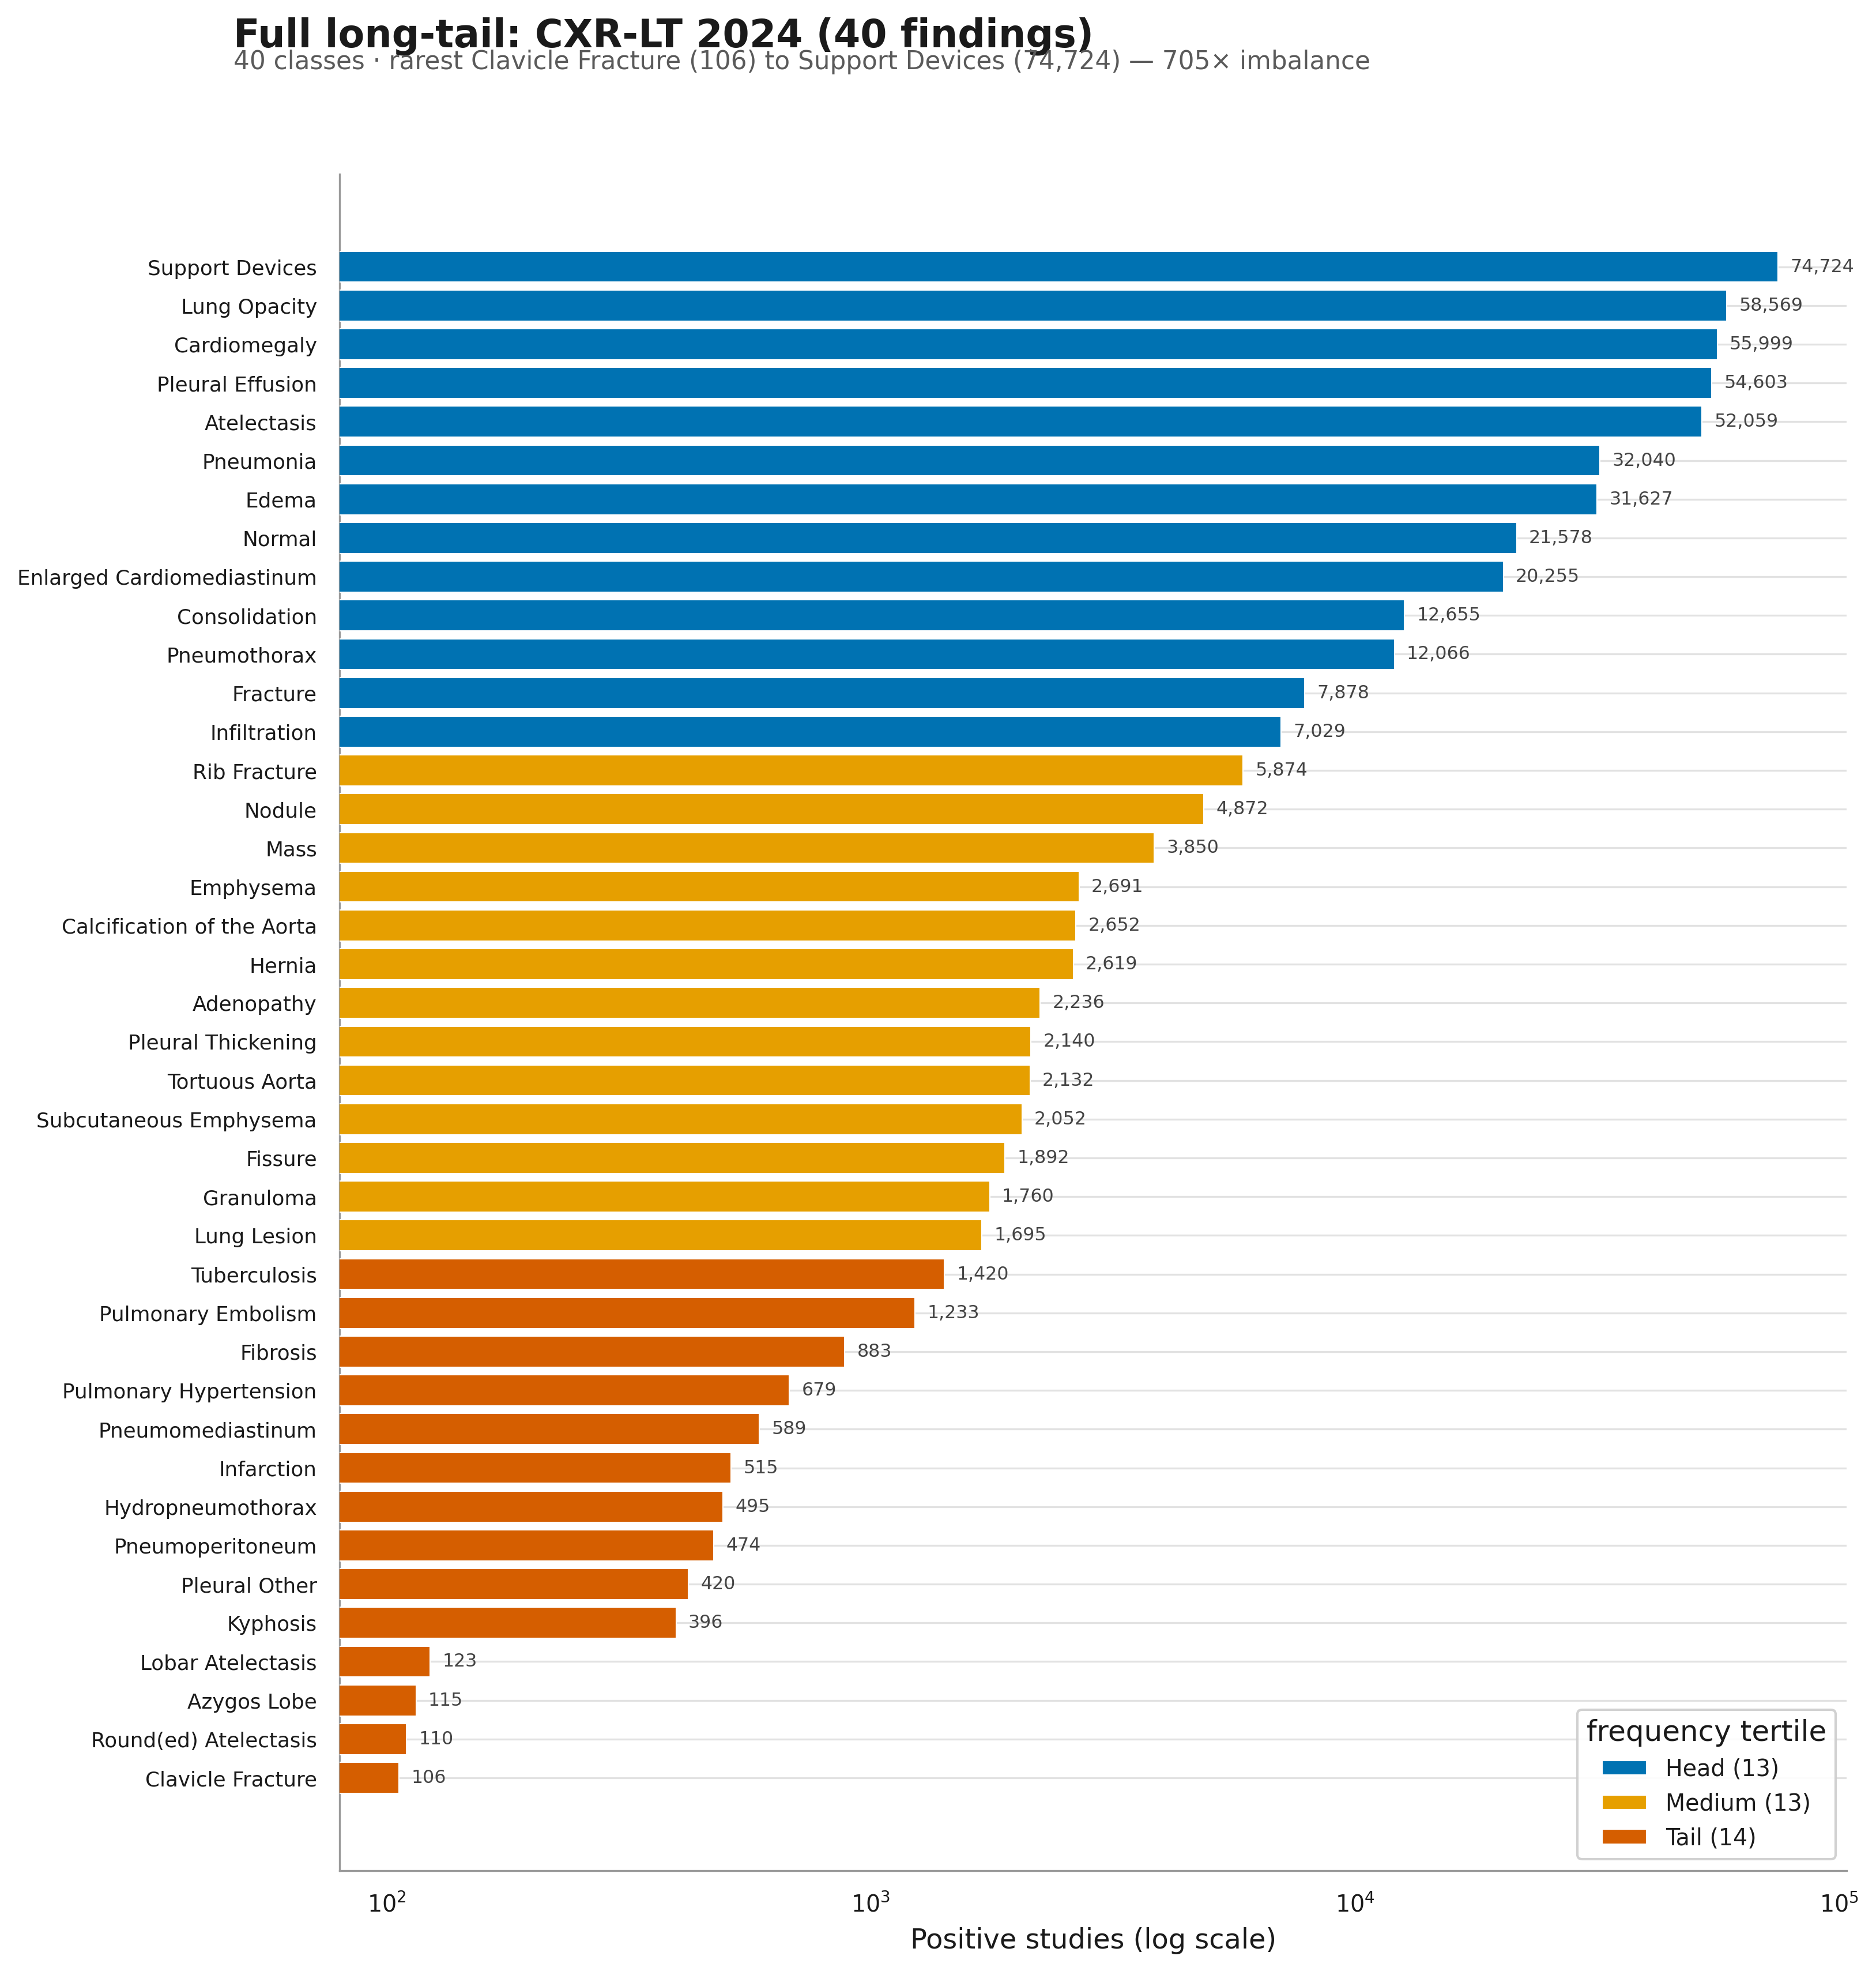

In [5]:
p7 = OUT_DIR / "fig7_longtail40.png"
mx.fig_longtail40(FIG_CSV, p7)
display(Image(filename=str(p7)))

## Regenerate from the command line

```bash
python data/00-examine-data/make_eda_figures_extra.py
```

writes all four PNGs (plus vector PDFs) to `report/img/eda/`.